# SmartCheck HelpDesk Performance and Outstanding Tickets Analysis Report(RBPL)

## Analysis of In-Progress Tickets, Resolution Bottlenecks, and Operational Improvement Opportunities.

### Librabies used for the coding

In [45]:
import pandas as pd
import numpy as np
from IPython.display import display
import re
import matplotlib.pyplot as plt
import seaborn as sns

### Imported the Help Desk Excel report from the beginning of the year till date

In [46]:
file_path = r"C:\Users\Moses\Downloads\HelpDesk Report_20260918144033987.xlsx"

df = pd.read_excel(file_path, header=2)

### Checked the data to give insight 

In [47]:
print(df.columns.tolist())

['SNO', 'Date', 'Complaint ID', 'Location', 'Sub-Location', 'Category', 'Sub-Category', 'Complaint', 'Description', 'Raised By', 'Source', 'Priority', 'Assigned To', 'Status', 'Closed By', 'Ticket Age', 'Sch Closing Date', 'Closing Date', 'Remarks', 'SLA', 'Rating']


In [48]:
print(df.shape)

(343, 21)


In [49]:
important_columns = [
    "SNO",
    "Date",
    "Complaint ID",
    "Location",
    "Category",
    "Sub-Category",
    "Complaint",
    "Assigned To",
    "Status",
    "Ticket Age",
    "Remarks",
    "SLA"
]

display(df[important_columns])

,SNO,Date,Complaint ID,Location,Category,Sub-Category,Complaint,Assigned To,Status,Ticket Age,Remarks,SLA
0,1,05-01-2026 08:14 AM,CT26010578761 - Complaint,2nd floor,Air Conditioning,NaN,AC is not functioning,Olufunsho Olusegun,Closed - L4,4 Days 6 Hrs 15 Mins,Cooling ok.,Outside SLA
1,2,05-01-2026 09:17 AM,CT26010544522 - Complaint,6th floor,Air Conditioning,NaN,Office is hot,Olufunsho Olusegun,Completed - L4,4 Days 5 Hrs 12 Mins,Cooling ok,Outside SLA
2,3,05-01-2026 12:06 PM,CT26010580673 - Complaint,8th floor,Air Conditioning,NaN,Air conditioning,Olufunsho Olusegun,Closed - L4,4 Days 2 Hrs 22 Mins,Cooling ok.,Outside SLA
3,4,05-01-2026 12:21 PM,CT26010528784 - Complaint,6th floor,Electrical,NaN,Hand dryer not working,Ariyo Adedokun,Completed - L3,1 Day 5 Hrs 32 Mins,Switch turned on.,Outside SLA
4,5,05-01-2026 02:44 PM,CT26010503365 - Complaint,7th floor,Air Conditioning,NaN,AC is not cooling,Olufunsho Olusegun,Closed - L4,3 Days 23 Hrs 44 Mins,cooling ok.,Outside SLA
...,...,...,...,...,...,...,...,...,...,...,...,...
338,339,04-09-2026 01:56 PM,CT26090404306 - Complaint,6th floor,Air Conditioning,NaN,Air conditioner is too much,Olufunsho Olusegun,Closed - L2,1 Hr 53 Mins,Done,Outside SLA
339,340,08-09-2026 08:45 AM,CT26090815507 - Complaint,1st floor,Electrical,NaN,Bad light bulb,Ariyo Adedokun,Closed - L2,8 Hrs 11 Mins,Done,Outside SLA
340,341,11-09-2026 01:06 PM,CT26091135688 - Complaint,9th floor,Facility Condition Assessment (FCA),NaN,Black Particles Figment,Olufunsho Olusegun,InProgress,7 Days 33 Mins,"Mr. Funsho, please look into this and get it s...",-
341,342,14-09-2026 11:20 AM,CT26091484719 - Complaint,6th floor,Plumbing,No water in the Rest-room,No water in the rest-room,Daniel Uwa,Closed - L3,1 Day 5 Hrs 50 Mins,Done,Outside SLA


In [50]:
display(df[important_columns].head())

,SNO,Date,Complaint ID,Location,Category,Sub-Category,Complaint,Assigned To,Status,Ticket Age,Remarks,SLA
0,1,05-01-2026 08:14 AM,CT26010578761 - Complaint,2nd floor,Air Conditioning,NaN,AC is not functioning,Olufunsho Olusegun,Closed - L4,4 Days 6 Hrs 15 Mins,Cooling ok.,Outside SLA
1,2,05-01-2026 09:17 AM,CT26010544522 - Complaint,6th floor,Air Conditioning,NaN,Office is hot,Olufunsho Olusegun,Completed - L4,4 Days 5 Hrs 12 Mins,Cooling ok,Outside SLA
2,3,05-01-2026 12:06 PM,CT26010580673 - Complaint,8th floor,Air Conditioning,NaN,Air conditioning,Olufunsho Olusegun,Closed - L4,4 Days 2 Hrs 22 Mins,Cooling ok.,Outside SLA
3,4,05-01-2026 12:21 PM,CT26010528784 - Complaint,6th floor,Electrical,NaN,Hand dryer not working,Ariyo Adedokun,Completed - L3,1 Day 5 Hrs 32 Mins,Switch turned on.,Outside SLA
4,5,05-01-2026 02:44 PM,CT26010503365 - Complaint,7th floor,Air Conditioning,NaN,AC is not cooling,Olufunsho Olusegun,Closed - L4,3 Days 23 Hrs 44 Mins,cooling ok.,Outside SLA


In [51]:
print(df[important_columns].isnull().sum())

SNO               0
Date              0
Complaint ID      0
Location          0
Category          0
Sub-Category    168
Complaint         0
Assigned To       0
Status            0
Ticket Age        1
Remarks           5
SLA               0
dtype: int64


In [52]:
print(df["Status"].value_counts())

Status
Completed - L6     63
Completed - L5     46
Completed          40
Closed             27
Closed - L6        24
Completed - L4     20
Completed - L2     20
Completed - L3     17
Closed - L5        17
InProgress - L6    15
Rejected           14
Closed - L2        12
Closed - L4        10
Completed - L1      8
Closed - L3         7
InProgress          3
Name: count, dtype: int64


### Understand ticket statuses

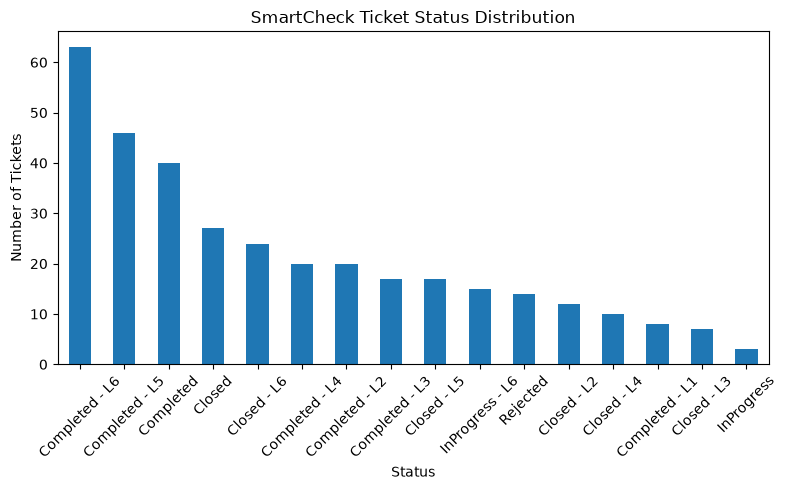

In [53]:
df["Status"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("SmartCheck Ticket Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Filtered all in-progress tickets

In [54]:
in_progress = df[
    df["Status"].astype(str).str.strip().str.lower().str.startswith("inprogress")
].copy()

In [55]:
display(in_progress)

,SNO,Date,Complaint ID,Location,Sub-Location,Category,Sub-Category,Complaint,Description,Raised By,...,Priority,Assigned To,Status,Closed By,Ticket Age,Sch Closing Date,Closing Date,Remarks,SLA,Rating
124,125,17-02-2026 03:26 PM,CT260217825094 - Complaint,9th floor,Janitor's room,Plumbing,Water spillage on the floor,Broken marble and faulty sink placement,Marble surrounding sink is broken and weak,Name - Faith Ometere Gadimoh | Mobile - 08085...,...,LOW,Daniel Uwa,InProgress - L6,-,7 Months 2 Days 22 Hrs 14 Mins,17-02-2026 04:26 PM,,"Mr. Daniel, please look into this and get it s...",-,-
131,132,19-02-2026 01:50 PM,CT2602192242101 - Complaint,Upper Basement,NaN,Civil,NaN,Maintenance toilet,Faulty door frame,Name - Faith Ometere Gadimoh | Mobile - 08085...,...,LOW,Daniel Uwa,InProgress - L6,-,7 Months 23 Hrs 50 Mins,19-02-2026 01:50 PM,,"Mr. Daniel, please look into this and get it s...",-,-
234,235,01-06-2026 02:29 PM,CT26060172461 - Complaint,Outer Surrounding,NaN,Civil,NaN,Building cleaning,Facade cleaning,Name - Salami Ebo | Mobile - 8062414024 | Emai...,...,LOW,Ehijele Ivbarialu,InProgress - L6,-,3 Months 18 Days 23 Hrs 10 Mins,01-06-2026 03:29 PM,,"Ehijele, please follow up with the facade clea...",-,-
249,250,03-06-2026 04:32 PM,CT260603193016 - Complaint,Upper Basement,NaN,INCIDENT MANAGEMENT REPORTING,Structural & Architectural - Building integrit...,Deep cracks on the wall,Deep cracks on the wall,Name - Faith Ometere Gadimoh | Mobile - 08085...,...,LOW,Ehijele Ivbarialu,InProgress,-,3 Months 16 Days 21 Hrs 8 Mins,03-06-2026 04:32 PM,,"Mr. Ehijele, please look into this and get it ...",-,-
294,295,13-07-2026 05:05 PM,CT260713450710 - Complaint,11th floor,NaN,Facility,NaN,Water leakage.,We are currently experiencing leakages that ar...,Optiva Capital Partners,...,LOW,Daniel Uwa,InProgress - L6,-,2 Months 6 Days 20 Hrs 35 Mins,13-07-2026 06:05 PM,,We have carried out some work on the terraces....,-,-
312,313,31-07-2026 10:50 AM,CT260731882928 - Complaint,9th floor,Rear Lobbies,Civil,NaN,Temporary POP ceiling - coridor to the pantry,The wooden temporary cover for the ceiling is ...,Name - Faith Ometere Gadimoh | Mobile - 08085...,...,NaN,Ariyo Adedokun,InProgress,-,1 Month 19 Days 2 Hrs 50 Mins,31-07-2026 11:50 AM,,Please get it done quickly,-,-
321,322,28-08-2026 02:29 PM,CT26082884085 - Complaint,12th floor,female toilet,Plumbing,NaN,Stench from the drain,A pungent smell is being emitted from the drai...,Name - Faith Ometere Gadimoh | Mobile - 08085...,...,LOW,Daniel Uwa,InProgress - L6,-,20 Days 23 Hrs 11 Mins,28-08-2026 03:29 PM,,"Mr. Daniel, please look into this and get it s...",-,-
324,325,28-08-2026 02:45 PM,CT26082828008 - Complaint,10th floor,NaN,Civil,NaN,Peeling of wall paint,Peeling of wall paint,Name - Faith Ometere Gadimoh | Mobile - 08085...,...,LOW,Daniel Uwa,InProgress - L6,-,20 Days 22 Hrs 54 Mins,28-08-2026 03:45 PM,,"Mr. Daniel, please look into this and get it s...",-,-
325,326,28-08-2026 03:40 PM,CT26082849729 - Complaint,Ground floor,NaN,Facility,NaN,Deteriorated rubber mat,Deteriorated rubber mat at the access control ...,Name - Faith Ometere Gadimoh | Mobile - 08085...,...,LOW,Prince Jonah,InProgress - L6,-,20 Days 22 Hrs,28-08-2026 04:40 PM,,"Mr. Prince, please look into this and get it s...",-,-
326,327,28-08-2026 03:42 PM,CT260828052210 - Complaint,Ground floor,Reception,Facility,NaN,Deteriorating foot rug,Deteriorating foot rug at the reception,Name - Faith Ometere Gadimoh | Mobile - 08085...,...,LOW,Prince Jonah,InProgress - L6,-,20 Days 21 Hrs 58 Mins,28-08-2026 04:42 PM,,"Mr. Prince, please look into this and get it s...",-,-


In [56]:
print("Total In-Progress Tickets:", len(in_progress))

Total In-Progress Tickets: 18


In [57]:
display(
    in_progress[
        ["Date", "Location", "Category", "Complaint",
         "Assigned To", "Ticket Age", "Remarks"]
    ]
)

,Date,Location,Category,Complaint,Assigned To,Ticket Age,Remarks
124,17-02-2026 03:26 PM,9th floor,Plumbing,Broken marble and faulty sink placement,Daniel Uwa,7 Months 2 Days 22 Hrs 14 Mins,"Mr. Daniel, please look into this and get it s..."
131,19-02-2026 01:50 PM,Upper Basement,Civil,Maintenance toilet,Daniel Uwa,7 Months 23 Hrs 50 Mins,"Mr. Daniel, please look into this and get it s..."
234,01-06-2026 02:29 PM,Outer Surrounding,Civil,Building cleaning,Ehijele Ivbarialu,3 Months 18 Days 23 Hrs 10 Mins,"Ehijele, please follow up with the facade clea..."
249,03-06-2026 04:32 PM,Upper Basement,INCIDENT MANAGEMENT REPORTING,Deep cracks on the wall,Ehijele Ivbarialu,3 Months 16 Days 21 Hrs 8 Mins,"Mr. Ehijele, please look into this and get it ..."
294,13-07-2026 05:05 PM,11th floor,Facility,Water leakage.,Daniel Uwa,2 Months 6 Days 20 Hrs 35 Mins,We have carried out some work on the terraces....
312,31-07-2026 10:50 AM,9th floor,Civil,Temporary POP ceiling - coridor to the pantry,Ariyo Adedokun,1 Month 19 Days 2 Hrs 50 Mins,Please get it done quickly
321,28-08-2026 02:29 PM,12th floor,Plumbing,Stench from the drain,Daniel Uwa,20 Days 23 Hrs 11 Mins,"Mr. Daniel, please look into this and get it s..."
324,28-08-2026 02:45 PM,10th floor,Civil,Peeling of wall paint,Daniel Uwa,20 Days 22 Hrs 54 Mins,"Mr. Daniel, please look into this and get it s..."
325,28-08-2026 03:40 PM,Ground floor,Facility,Deteriorated rubber mat,Prince Jonah,20 Days 22 Hrs,"Mr. Prince, please look into this and get it s..."
326,28-08-2026 03:42 PM,Ground floor,Facility,Deteriorating foot rug,Prince Jonah,20 Days 21 Hrs 58 Mins,"Mr. Prince, please look into this and get it s..."


### Identified why tickets are still in progress

In [58]:
for index, row in in_progress.iterrows():

    print("=" * 80)

    print("Complaint:", row.get("Complaint"))

    print("Remarks:", row.get("Remarks"))

    print("Assigned To:", row.get("Assigned To"))

    print("Ticket Age:", row.get("Ticket Age"))

    print()

Complaint: Broken marble and faulty sink placement
Remarks: Mr. Daniel, please look into this and get it sorted asap.
Assigned To: Daniel Uwa
Ticket Age: 7 Months 2 Days 22 Hrs 14 Mins 

Complaint: Maintenance toilet
Remarks: Mr. Daniel, please look into this and get it sorted asap.
Assigned To: Daniel Uwa
Ticket Age: 7 Months 23 Hrs 50 Mins 

Complaint: Building cleaning
Remarks: Ehijele, please follow up with the facade cleaning of the building
Assigned To: Ehijele Ivbarialu 
Ticket Age: 3 Months 18 Days 23 Hrs 10 Mins 

Complaint: Deep cracks on the wall
Remarks: Mr. Ehijele, please look into this and get it sorted asap.
Assigned To: Ehijele Ivbarialu 
Ticket Age: 3 Months 16 Days 21 Hrs 8 Mins 

Complaint: Water leakage.
Remarks: We have carried out some work on the terraces. We shall wait for rain to confirm the result.
Assigned To: Daniel Uwa
Ticket Age: 2 Months 6 Days 20 Hrs 35 Mins 

Complaint: Temporary POP ceiling - coridor to the pantry
Remarks: Please get it done quickly
A

### Created a reason classification column

In [59]:
reason_mapping = {

    "Broken marble and faulty sink placement":
        "Assigned for Follow-up",

    "Maintenance toilet":
        "Assigned for Follow-up",

    "Building cleaning":
        "Facade Cleaning Follow-up",

    "Deep cracks on the wall":
        "Assigned for Follow-up",

    "Water leakage.":
        "Awaiting Rain to Confirm Result",

    "Temporary POP ceiling - coridor to the pantry":
        "Assigned for Follow-up",

    "Stench from the drain":
        "Assigned for Follow-up",

    "Peeling of wall paint":
        "Assigned for Follow-up",

    "Deteriorated rubber mat":
        "Assigned for Follow-up",

    "Deteriorating foot rug":
        "Assigned for Follow-up",

    "Displaced aluminium footing at the access control area":
        "Assigned for Follow-up",

    "Dust on the wooden ceiling and chandelier":
        "Assigned for Follow-up",

    "Rooftop ceiling painting peeling off":
        "Assigned for Follow-up",

    "Worn out wooden caution sign":
        "Assigned for Follow-up",

    "Displaced wooden caution sign":
        "Assigned for Follow-up",

    "Stained and dirty wall paints":
        "Assigned for Follow-up",

    "water not coming out from the left hand water basin":
        "Assigned for Follow-up",

    "Black Particles Figment":
        "Assigned for Follow-up"
}

### Analyzed ticket aging

In [60]:
in_progress["Delay Reason"] = (
    in_progress["Complaint"]
    .map(reason_mapping)
    .fillna("Reason Not Documented")
)

In [61]:
from IPython.display import display

display(
    in_progress[
        [
            "SNO",
            "Complaint",
            "Assigned To",
            "Ticket Age",
            "Remarks",
            "Delay Reason"
        ]
    ]
)

,SNO,Complaint,Assigned To,Ticket Age,Remarks,Delay Reason
124,125,Broken marble and faulty sink placement,Daniel Uwa,7 Months 2 Days 22 Hrs 14 Mins,"Mr. Daniel, please look into this and get it s...",Assigned for Follow-up
131,132,Maintenance toilet,Daniel Uwa,7 Months 23 Hrs 50 Mins,"Mr. Daniel, please look into this and get it s...",Assigned for Follow-up
234,235,Building cleaning,Ehijele Ivbarialu,3 Months 18 Days 23 Hrs 10 Mins,"Ehijele, please follow up with the facade clea...",Facade Cleaning Follow-up
249,250,Deep cracks on the wall,Ehijele Ivbarialu,3 Months 16 Days 21 Hrs 8 Mins,"Mr. Ehijele, please look into this and get it ...",Assigned for Follow-up
294,295,Water leakage.,Daniel Uwa,2 Months 6 Days 20 Hrs 35 Mins,We have carried out some work on the terraces....,Awaiting Rain to Confirm Result
312,313,Temporary POP ceiling - coridor to the pantry,Ariyo Adedokun,1 Month 19 Days 2 Hrs 50 Mins,Please get it done quickly,Assigned for Follow-up
321,322,Stench from the drain,Daniel Uwa,20 Days 23 Hrs 11 Mins,"Mr. Daniel, please look into this and get it s...",Assigned for Follow-up
324,325,Peeling of wall paint,Daniel Uwa,20 Days 22 Hrs 54 Mins,"Mr. Daniel, please look into this and get it s...",Assigned for Follow-up
325,326,Deteriorated rubber mat,Prince Jonah,20 Days 22 Hrs,"Mr. Prince, please look into this and get it s...",Assigned for Follow-up
326,327,Deteriorating foot rug,Prince Jonah,20 Days 21 Hrs 58 Mins,"Mr. Prince, please look into this and get it s...",Assigned for Follow-up


In [62]:
reason_summary = (
    in_progress["Delay Reason"]
    .value_counts()
    .reset_index()
)

reason_summary.columns = [
    "Delay Reason",
    "Number of Tickets"
]

display(reason_summary)

,Delay Reason,Number of Tickets
0,Assigned for Follow-up,14
1,Reason Not Documented,2
2,Facade Cleaning Follow-up,1
3,Awaiting Rain to Confirm Result,1


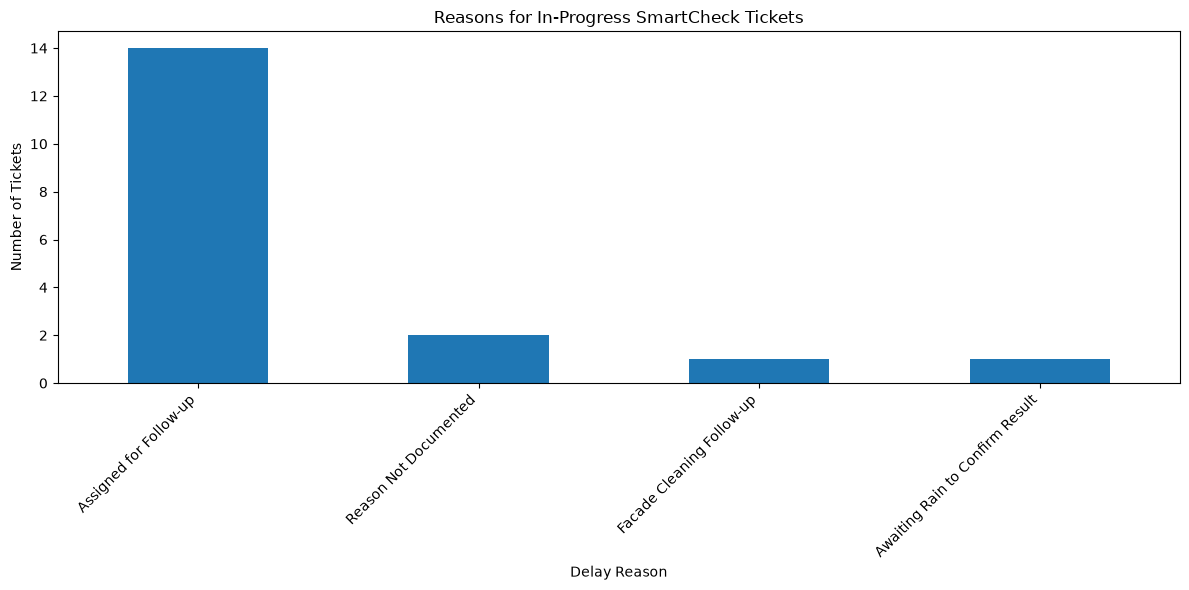

In [63]:
import matplotlib.pyplot as plt

reason_summary.set_index("Delay Reason")[
    "Number of Tickets"
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Reasons for In-Progress SmartCheck Tickets")
plt.xlabel("Delay Reason")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Analyzed assigned personnel

In [64]:
assigned_summary = (
    in_progress.groupby("Assigned To")
    .size()
    .reset_index(name="In-Progress Tickets")
    .sort_values("In-Progress Tickets", ascending=False)
)

display(assigned_summary)

,Assigned To,In-Progress Tickets
1,Daniel Uwa,6
2,Ehijele Ivbarialu,6
5,Prince Jonah,3
0,Ariyo Adedokun,1
3,Lawal Muhammed,1
4,Olufunsho Olusegun,1


In [65]:
print(in_progress["Ticket Age"].head(20))

124     7 Months 2 Days 22 Hrs 14 Mins 
131            7 Months 23 Hrs 50 Mins 
234    3 Months 18 Days 23 Hrs 10 Mins 
249     3 Months 16 Days 21 Hrs 8 Mins 
294     2 Months 6 Days 20 Hrs 35 Mins 
312      1 Month 19 Days 2 Hrs 50 Mins 
321             20 Days 23 Hrs 11 Mins 
324             20 Days 22 Hrs 54 Mins 
325                     20 Days 22 Hrs 
326             20 Days 21 Hrs 58 Mins 
327             20 Days 21 Hrs 52 Mins 
328             20 Days 21 Hrs 49 Mins 
329             20 Days 19 Hrs 13 Mins 
330             20 Days 19 Hrs 10 Mins 
331              20 Days 19 Hrs 9 Mins 
332              20 Days 19 Hrs 5 Mins 
337              14 Days 2 Hrs 52 Mins 
340                     7 Days 33 Mins 
Name: Ticket Age, dtype: str


In [66]:
def convert_age_to_days(age):

    if pd.isna(age):
        return np.nan

    age = str(age)

    months = re.search(r"(\d+)\s+Month", age)
    days = re.search(r"(\d+)\s+Day", age)
    hours = re.search(r"(\d+)\s+Hr", age)

    months_value = int(months.group(1)) if months else 0
    days_value = int(days.group(1)) if days else 0
    hours_value = int(hours.group(1)) if hours else 0

    total_days = (
        months_value * 30
        + days_value
        + hours_value / 24
    )

    return total_days

In [67]:
in_progress["Age in Days"] = in_progress["Ticket Age"].apply(
    convert_age_to_days
)

In [68]:
oldest_tickets = in_progress.sort_values(
    by="Age in Days",
    ascending=False
)

display(
    oldest_tickets[
        ["SNO", "Complaint", "Ticket Age", "Age in Days", "Assigned To"]
    ].head(20)
)

,SNO,Complaint,Ticket Age,Age in Days,Assigned To
124,125,Broken marble and faulty sink placement,7 Months 2 Days 22 Hrs 14 Mins,212.916667,Daniel Uwa
131,132,Maintenance toilet,7 Months 23 Hrs 50 Mins,210.958333,Daniel Uwa
234,235,Building cleaning,3 Months 18 Days 23 Hrs 10 Mins,108.958333,Ehijele Ivbarialu
249,250,Deep cracks on the wall,3 Months 16 Days 21 Hrs 8 Mins,106.875000,Ehijele Ivbarialu
294,295,Water leakage.,2 Months 6 Days 20 Hrs 35 Mins,66.833333,Daniel Uwa
312,313,Temporary POP ceiling - coridor to the pantry,1 Month 19 Days 2 Hrs 50 Mins,49.083333,Ariyo Adedokun
321,322,Stench from the drain,20 Days 23 Hrs 11 Mins,20.958333,Daniel Uwa
324,325,Peeling of wall paint,20 Days 22 Hrs 54 Mins,20.916667,Daniel Uwa
325,326,Deteriorated rubber mat,20 Days 22 Hrs,20.916667,Prince Jonah
326,327,Deteriorating foot rug,20 Days 21 Hrs 58 Mins,20.875000,Prince Jonah


In [69]:
def aging_category(days):

    if pd.isna(days):
        return "Unknown"

    if days <= 7:
        return "0-7 Days"

    elif days <= 30:
        return "8-30 Days"

    elif days <= 90:
        return "31-90 Days"

    else:
        return "Above 90 Days"

In [70]:
in_progress["Aging Category"] = in_progress["Age in Days"].apply(
    aging_category
)

In [71]:
print(
    in_progress["Aging Category"].value_counts()
)

Aging Category
8-30 Days        11
Above 90 Days     4
31-90 Days        2
0-7 Days          1
Name: count, dtype: int64


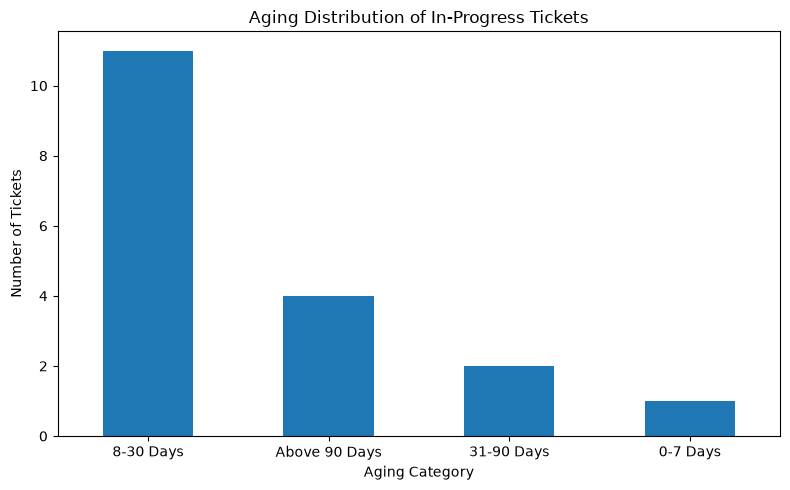

In [72]:
in_progress["Aging Category"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Aging Distribution of In-Progress Tickets")
plt.xlabel("Aging Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [73]:
assigned_analysis = (
    in_progress["Assigned To"]
    .fillna("Unassigned")
    .value_counts()
)

In [74]:
print(assigned_analysis)

Assigned To
Daniel Uwa            6
Ehijele Ivbarialu     6
Prince Jonah          3
Ariyo Adedokun        1
Lawal Muhammed        1
Olufunsho Olusegun    1
Name: count, dtype: int64


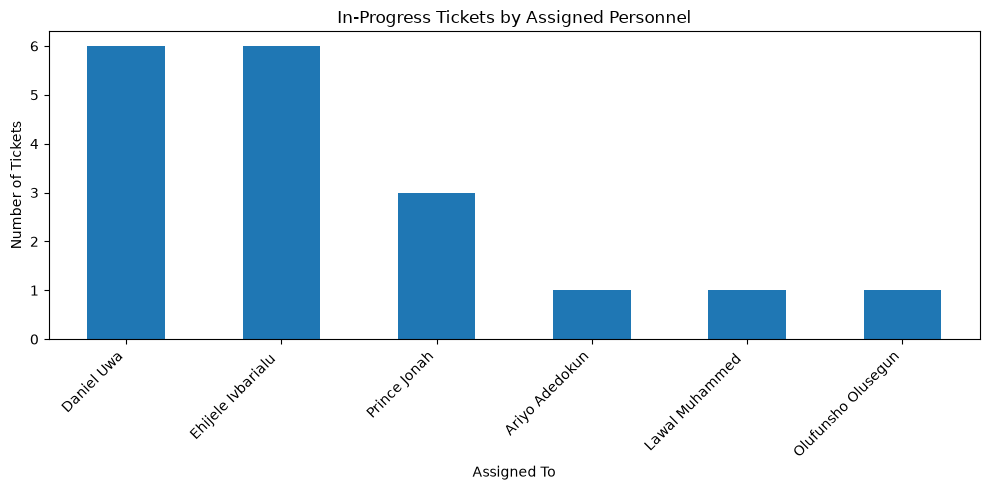

In [75]:
assigned_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("In-Progress Tickets by Assigned Personnel")
plt.xlabel("Assigned To")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Analyze locations and categories

#### By location

In [76]:
location_analysis = (
    in_progress["Location"]
    .fillna("Unknown")
    .value_counts()
)

print(location_analysis)

Location
Ground floor          4
9th floor             3
Upper Basement        3
Outer Surrounding     1
11th floor            1
12th floor            1
10th floor            1
Roof Top              1
Lower Basement        1
RBPL                  1
5th floor             1
Name: count, dtype: int64


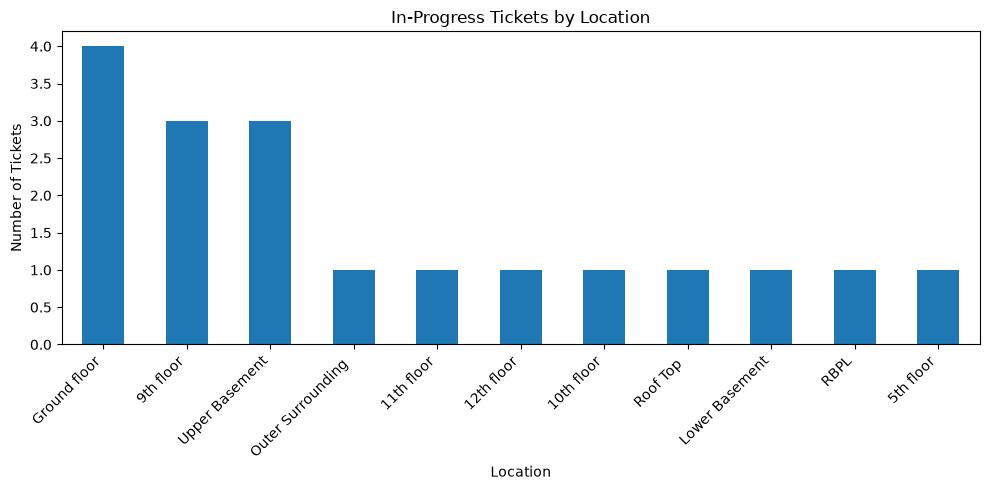

In [77]:
location_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("In-Progress Tickets by Location")
plt.xlabel("Location")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### By category

In [78]:
category_analysis = (
    in_progress["Category"]
    .fillna("Unknown")
    .value_counts()
)

print(category_analysis)

Category
Facility                               9
Civil                                  5
Plumbing                               2
INCIDENT MANAGEMENT REPORTING          1
Facility Condition Assessment (FCA)    1
Name: count, dtype: int64


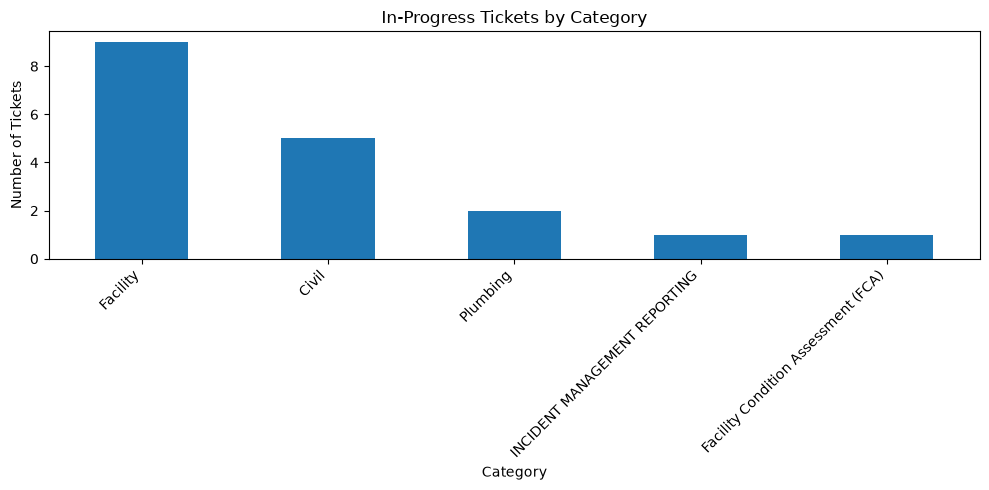

In [79]:
category_analysis.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("In-Progress Tickets by Category")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Analyze SLA performance

In [80]:
print(df["SLA"].value_counts(dropna=False))

SLA
Outside SLA    303
 -              32
WithIn SLA       8
Name: count, dtype: int64


In [81]:
sla_analysis = df["SLA"].value_counts(dropna=False)

print(sla_analysis)

SLA
Outside SLA    303
 -              32
WithIn SLA       8
Name: count, dtype: int64


In [82]:
print(
    in_progress["SLA"].value_counts(dropna=False)
)

SLA
-     18
Name: count, dtype: int64


### CREATED A SUMMARY

In [83]:
total_tickets = len(df)

total_in_progress = len(in_progress)

older_than_30 = (
    in_progress["Age in Days"] > 30
).sum()

older_than_90 = (
    in_progress["Age in Days"] > 90
).sum()

print("SMARTCHECK HELPDESK SUMMARY")
print("=" * 40)

print("Total Tickets:", total_tickets)

print("In Progress:", total_in_progress)

print("In Progress Above 30 Days:", older_than_30)

print("In Progress Above 90 Days:", older_than_90)

SMARTCHECK HELPDESK SUMMARY
Total Tickets: 343
In Progress: 18
In Progress Above 30 Days: 6
In Progress Above 90 Days: 4


In [84]:
in_progress_percentage = (
    total_in_progress / total_tickets
) * 100

print(
    f"In-Progress Percentage: {in_progress_percentage:.2f}%"
)

In-Progress Percentage: 5.25%


### Converted the Analysis to excel

In [85]:
output_file = r"C:\Users\Moses\Downloads\SmartCheck_Analysis.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    df.to_excel(
        writer,
        sheet_name="All Tickets",
        index=False
    )

    in_progress.to_excel(
        writer,
        sheet_name="In Progress",
        index=False
    )

    assigned_analysis.to_frame(
        name="Ticket Count"
    ).to_excel(
        writer,
        sheet_name="By Assignee"
    )

    category_analysis.to_frame(
        name="Ticket Count"
    ).to_excel(
        writer,
        sheet_name="By Category"
    )

print("Analysis saved successfully!")

Analysis saved successfully!
